# Práctica 4. Aplicación de la técnica de validación cruzada en Python

Integrantes
*   Aguirre Lanto Victor Manuel
*   Gasca Fragoso Pedro
*   Guevara Badillo Areli Alejandra
*   Montiel Toro Arael de Jesús
*   Ramírez Lozano Gael Martín








Ejemplo de uso de

```
crooss_validate()
```



In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

# 1. Crear un conjunto de datos de ejemplo
X, y = make_classification(n_samples=100, n_features=20, n_informative=2, n_redundant=10, random_state=42)

# 2. Inicializar el modelo
modelo = RandomForestClassifier(random_state=42)

# 3. Definir las métricas de evaluación
metricas = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# 4. Ejecutar cross_validate()
#    - cv=5: Validación cruzada de 5 pliegues.
#    - scoring=metricas: Evalúa las cuatro métricas definidas.
#    - return_train_score=True: Incluye las puntuaciones del conjunto de entrenamiento.
resultados_cv = cross_validate(modelo, X, y, cv=5, scoring=metricas, return_train_score=True)

# 5. Imprimir los resultados
print("Resultados de la Validación Cruzada:")
print("-" * 35)

# Puntuaciones promedio en los pliegues de prueba (validación)
print(f"Precisión (Accuracy) en prueba: {np.mean(resultados_cv['test_accuracy']):.3f}")
print(f"Precisión (Precision) en prueba: {np.mean(resultados_cv['test_precision_macro']):.3f}")
print(f"Sensibilidad (Recall) en prueba: {np.mean(resultados_cv['test_recall_macro']):.3f}")
print(f"Puntuación F1 en prueba: {np.mean(resultados_cv['test_f1_macro']):.3f}")
print("-" * 35)

# Puntuaciones promedio en los pliegues de entrenamiento para verificar sobreajuste
print(f"Precisión (Accuracy) en entrenamiento: {np.mean(resultados_cv['train_accuracy']):.3f}")
print(f"Puntuación F1 en entrenamiento: {np.mean(resultados_cv['train_f1_macro']):.3f}")
print("-" * 35)

# Tiempos de ejecución
print(f"Tiempo promedio de ajuste (fit): {np.mean(resultados_cv['fit_time']):.3f} segundos")
print(f"Tiempo promedio de puntuación (score): {np.mean(resultados_cv['score_time']):.3f} segundos")

Resultados de la Validación Cruzada:
-----------------------------------
Precisión (Accuracy) en prueba: 0.970
Precisión (Precision) en prueba: 0.974
Sensibilidad (Recall) en prueba: 0.970
Puntuación F1 en prueba: 0.970
-----------------------------------
Precisión (Accuracy) en entrenamiento: 1.000
Puntuación F1 en entrenamiento: 1.000
-----------------------------------
Tiempo promedio de ajuste (fit): 0.409 segundos
Tiempo promedio de puntuación (score): 0.044 segundos


# Dataset Iris

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn import datasets

# Cargar un dataset de ejemplo
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Crear el clasificador Naive Bayes
clf = GaussianNB()

# Definir las métricas que deseas calcular
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Aplicar validación cruzada con múltiples métricas
scores = cross_validate(clf, X, y, cv=5, scoring=scoring)

# Imprimir los resultados de las métricas
print("Accuracy:", scores['test_accuracy'].mean())
print("Precision:", scores['test_precision_macro'].mean())
print("Recall:", scores['test_recall_macro'].mean())
print("F-score:", scores['test_f1_macro'].mean())

Accuracy: 0.9533333333333334
Precision: 0.9583838383838383
Recall: 0.9533333333333331
F-score: 0.9530472646262119


In [ ]:
!pip install tabulate

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

# Convertir el diccionario 'scores' en un DataFrame para que se vea mas bonito :D
df = pd.DataFrame({k: np.asarray(v) for k, v in scores.items()})

print("\n--- Matriz de Puntuajes (scores) ---")
display(df.round(6))


--- Matriz de Puntuajes (scores) ---


,fit_time,score_time,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,0.002776,0.019623,0.933333,0.933333,0.933333,0.933333
1,0.002129,0.011219,0.966667,0.969697,0.966667,0.966583
2,0.001677,0.009804,0.933333,0.944444,0.933333,0.932660
3,0.001809,0.009616,0.933333,0.944444,0.933333,0.932660
4,0.001647,0.009305,1.000000,1.000000,1.000000,1.000000


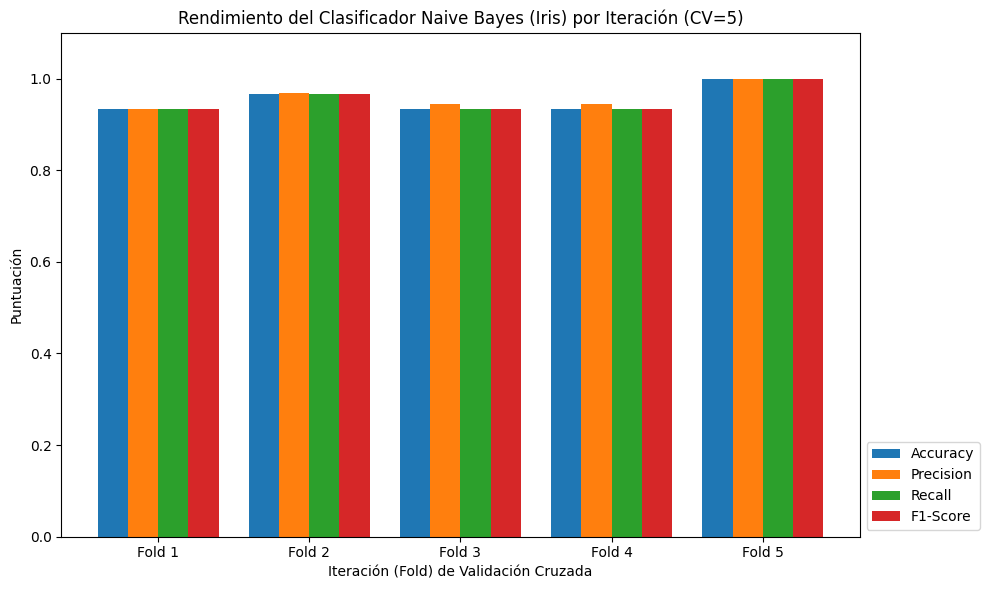

In [ ]:
# Extraer los datos de las métricas para la gráfica
metrics = ['test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_f1_macro']
results = {m: scores[m] for m in metrics}

# Nombres más amigables para el eje Y
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Preparar la gráfica
n_folds = len(scores['test_accuracy']) # Número de iteraciones (cv=5)
x = np.arange(n_folds)  # Posiciones para las barras
width = 0.2         # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar las barras para cada métrica
rects1 = ax.bar(x - 1.5*width, results['test_accuracy'], width, label=metric_names[0])
rects2 = ax.bar(x - 0.5*width, results['test_precision_macro'], width, label=metric_names[1])
rects3 = ax.bar(x + 0.5*width, results['test_recall_macro'], width, label=metric_names[2])
rects4 = ax.bar(x + 1.5*width, results['test_f1_macro'], width, label=metric_names[3])

# Añadir etiquetas, título y leyenda
ax.set_ylabel('Puntuación')
ax.set_xlabel('Iteración (Fold) de Validación Cruzada')
ax.set_title('Rendimiento del Clasificador Naive Bayes (Iris) por Iteración (CV=5)')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(n_folds)])
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))
ax.set_ylim(0, 1.1) # Las puntuaciones van de 0 a 1

plt.tight_layout()
plt.show() # Mostrar la gráfica

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Separar en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Crear y entrenar el clasificador Naive Bayes
clf = GaussianNB()
clf.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba
y_pred = clf.predict(X_test)

# Calcular métricas (macro para que trate por igual cada clase)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# Imprimir resultados
print("Resultados (80% train / 20% test):")
print(f"Número de muestras de entrenamiento (80%): {len(X_train)}")
print(f"Número de muestras de prueba (20%): {len(X_test)}")
print("-" * 45)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (macro)")
print(f"Recall:    {recall:.4f} (macro)")
print(f"F1-score:  {f1:.4f} (macro)\n")

Resultados (80% train / 20% test):
Número de muestras de entrenamiento (80%): 120
Número de muestras de prueba (20%): 30
---------------------------------------------
Accuracy:  0.9667
Precision: 0.9697 (macro)
Recall:    0.9667 (macro)
F1-score:  0.9666 (macro)



# Dataset Vinos

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn import datasets

# Cargar el dataset de vinos (wine)
wine = datasets.load_wine()
X = wine.data
y = wine.target

# Crear el clasificador Naive Bayes
clf2 = GaussianNB()

# Definir las métricas que deseas calcular
scoring2 = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Aplicar validación cruzada con múltiples métricas
scores2 = cross_validate(clf2, X, y, cv=5, scoring=scoring2)

# Imprimir los resultados de las métricas (promedio de CV)
print("--- Resultados de Validación Cruzada (CV=5) (Promedios) ---")
print(f"Accuracy: {scores2['test_accuracy'].mean():.4f}")
print(f"Precision: {scores2['test_precision_macro'].mean():.4f}")
print(f"Recall: {scores2['test_recall_macro'].mean():.4f}")
print(f"F-score: {scores2['test_f1_macro'].mean():.4f}")

--- Resultados de Validación Cruzada (CV=5) (Promedios) ---
Accuracy: 0.9663
Precision: 0.9700
Recall: 0.9690
F-score: 0.9677


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convertir el diccionario 'scores' en un DataFrame para que se vea mas bonito :D
df = pd.DataFrame({k: np.asarray(v) for k, v in scores2.items()})

print("\n--- Matriz de Puntuajes (scores) ---")
display(df.round(6))


--- Matriz de Puntuajes (scores) ---


,fit_time,score_time,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,0.002044,0.011311,0.944444,0.944056,0.952381,0.945153
1,0.001895,0.012130,0.972222,0.969697,0.976190,0.971781
2,0.001882,0.019732,0.972222,0.977778,0.972222,0.974013
3,0.004166,0.023148,0.942857,0.958333,0.944444,0.947475
4,0.004313,0.014449,1.000000,1.000000,1.000000,1.000000


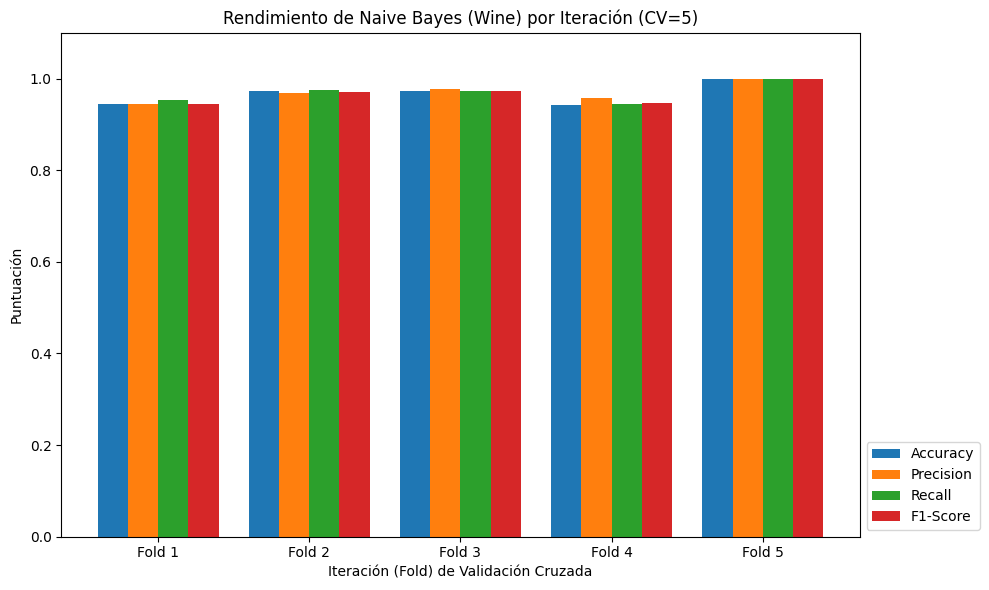

In [ ]:
# Extraer los datos de las métricas para la gráfica
metrics2 = ['test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_f1_macro']
results2 = {m: scores2[m] for m in metrics2}

# Nombres más amigables para el eje Y
metric_names2 = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Preparar la gráfica
n_folds = len(scores2['test_accuracy']) # Número de iteraciones (cv=5)
x = np.arange(n_folds)  # Posiciones para las barras
width = 0.2         # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar las barras para cada métrica
rects1 = ax.bar(x - 1.5*width, results2['test_accuracy'], width, label=metric_names[0])
rects2 = ax.bar(x - 0.5*width, results2['test_precision_macro'], width, label=metric_names[1])
rects3 = ax.bar(x + 0.5*width, results2['test_recall_macro'], width, label=metric_names[2])
rects4 = ax.bar(x + 1.5*width, results2['test_f1_macro'], width, label=metric_names[3])

# Añadir etiquetas, título y leyenda
ax.set_ylabel('Puntuación')
ax.set_xlabel('Iteración (Fold) de Validación Cruzada')
ax.set_title('Rendimiento de Naive Bayes (Wine) por Iteración (CV=5)')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(n_folds)])
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))
ax.set_ylim(0, 1.1) # Las puntuaciones van de 0 a 1

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Separar en 80% entrenamiento y 20% prueba
# Usamos las variables X e y del dataset Wine (cargadas en Parte 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Crear y entrenar el clasificador Naive Bayes
clf_split = GaussianNB() # Usamos una nueva instancia para claridad
clf_split.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba
y_pred = clf_split.predict(X_test)

# Calcular métricas (macro para que trate por igual cada clase)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# Imprimir resultados
print("\n--- Resultados (80% train / 20% test) ---")
print(f"Número de muestras de entrenamiento (80%): {len(X_train)}")
print(f"Número de muestras de prueba (20%): {len(X_test)}")
print("-" * 45)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (macro)")
print(f"Recall:    {recall:.4f} (macro)")
print(f"F1-score:  {f1:.4f} (macro)\n")


--- Resultados (80% train / 20% test) ---
Número de muestras de entrenamiento (80%): 142
Número de muestras de prueba (20%): 36
---------------------------------------------
Accuracy:  0.9722
Precision: 0.9744 (macro)
Recall:    0.9762 (macro)
F1-score:  0.9743 (macro)

